# Value Based Segmentation

Identify how much economic value each customer brings to the airline (AIAI) and group them based on financial contribution and profitability.

This helps the company answer:

“Who are our most valuable customers?”
“Which customers deserve premium attention, loyalty perks, or reactivation campaigns?”

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import cleaned and aggregated data
flights = pd.read_csv('../data/cleaned/flights_cleaned.csv')
customers = pd.read_csv('../data/aggregated/customers_aggregations.csv')

In [3]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,16574.0,549435.680825,258874.788435,100018.000000,326235.500000,550020.000000,771895.750000,999986.000000
Latitude,16574.0,47.174633,3.305623,42.984924,44.231171,46.087818,49.282730,60.721188
Longitude,16574.0,-91.840494,22.240412,-135.056840,-120.237660,-79.383186,-74.596184,-52.712578
Income,16574.0,37739.986787,30355.907587,0.000000,0.000000,34137.000000,62373.750000,99981.000000
Customer Lifetime Value,16574.0,7986.494716,6858.499179,1898.010000,3978.822500,5780.180000,8954.430000,83325.380000
IsActive,16574.0,0.864426,0.342346,0.000000,1.000000,1.000000,1.000000,1.000000
CustomerTenureDays,16574.0,2275.160251,1039.713176,-1924.000000,1659.000000,2348.000000,3121.000000,3848.000000
total_flights,16574.0,144.805056,81.723912,0.000000,73.000000,168.000000,207.000000,343.000000
total_flights_with_companions,16574.0,33.702063,22.299848,0.000000,15.000000,35.000000,50.000000,119.000000
total_distance,16574.0,287049.723989,163461.945565,0.000000,144610.425000,331463.550000,413197.350000,712729.600000


In [4]:
flights.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,596664.0,549435.680825,258867.195581,100018.0,326234.00,550020.0,771901.00,999986.0
Year,596664.0,2020.000000,0.816497,2019.0,2019.00,2020.0,2021.00,2021.0
Month,596664.0,6.500000,3.452055,1.0,3.75,6.5,9.25,12.0
NumFlights,596664.0,4.022363,5.015711,0.0,0.00,1.0,8.00,21.0
NumFlightsWithCompanions,596664.0,0.936168,1.968412,0.0,0.00,0.0,1.00,11.0
DistanceKM,596664.0,7973.603444,10269.174348,0.0,0.00,984.5,15400.00,42040.0
PointsAccumulated,596664.0,797.203290,1026.793920,0.0,0.00,98.0,1540.00,4204.0
PointsRedeemed,596664.0,236.469767,985.680370,0.0,0.00,0.0,0.00,7496.0
DollarCostPointsRedeemed,596664.0,2.336869,9.749377,0.0,0.00,0.0,0.00,74.0


## Create Value Metrics (feature engineering)

In [5]:
# Create the row: average distance per flight for each customer
# Divide the value of total distance by the number of flights
customers['Avg_Distance_Per_Flight'] = np.where(
    customers['total_flights'] > 0,
    customers['total_distance'] / customers['total_flights'],
    0
)
customers['Avg_Distance_Per_Flight'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 16574 entries, 0 to 16573
Series name: Avg_Distance_Per_Flight
Non-Null Count  Dtype  
--------------  -----  
16574 non-null  float64
dtypes: float64(1)
memory usage: 129.6 KB


In [6]:
# --- Schritt 1: Berechnung ---
customers['Avg_Distance_Per_Flight'] = np.where(
    customers['total_flights'] > 0,
    customers['total_distance'] / customers['total_flights'],
    0
)

# --- Schritt 2: Prüfung per Schleife ---
for idx, row in customers.iterrows():
    if row['Avg_Distance_Per_Flight'] > 13000:
        print(f"Kunde mit ID {row['Loyalty#']} hat einen ungewöhnlich hohen Wert: "
              f"{row['Avg_Distance_Per_Flight']:.2f}")

In [7]:
# Count the customers with Avg_Distance_Per_Flight > 13000
high_distance_customers = customers[customers['Avg_Distance_Per_Flight'] > 13000]
print(f"Anzahl der Kunden mit Avg_Distance_Per_Flight > 13000: {len(high_distance_customers)}")

Anzahl der Kunden mit Avg_Distance_Per_Flight > 13000: 0


In [8]:
# describe the new column Avg_Distance_Per_Flight
customers['Avg_Distance_Per_Flight'].describe()

count    16574.000000
mean      1864.942346
std        841.916044
min          0.000000
25%       1608.273197
50%       1933.637207
75%       2260.007893
max      12624.000000
Name: Avg_Distance_Per_Flight, dtype: float64

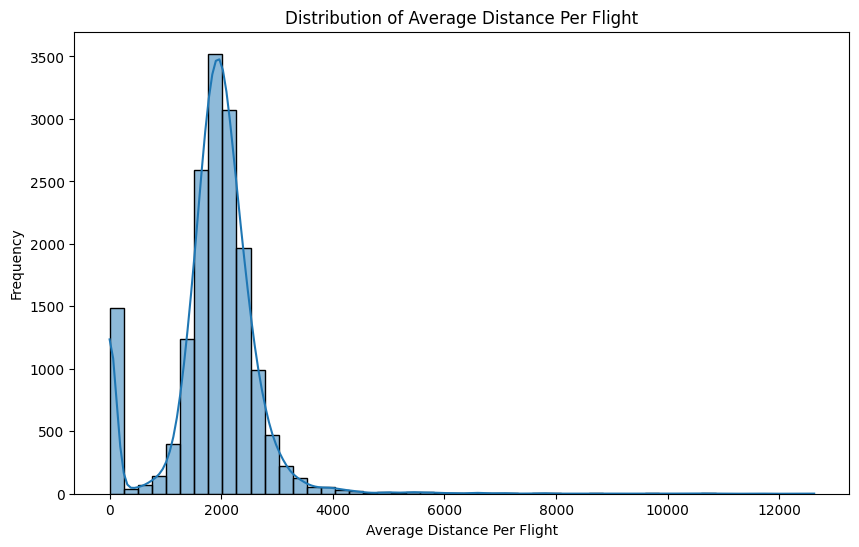

In [9]:
# Visualize the distribution of the new column Avg_Distance_Per_Flight 
plt.figure(figsize=(10, 6))
sns.histplot(customers['Avg_Distance_Per_Flight'], bins=50, kde=True)
plt.title('Distribution of Average Distance Per Flight')
plt.xlabel('Average Distance Per Flight')
plt.ylabel('Frequency')
plt.show()


In [10]:
# Count the Flights with more than 10000 km distance (Avg_Distance_Per_Flight > 10000)
customers_long_distance = customers[customers['Avg_Distance_Per_Flight'] > 10000]
print(f"Number of long distance flight customers (>10000 km): {len(customers_long_distance)}")

# Print the first 5 rows of these customers
customers_long_distance.head()

Number of long distance flight customers (>10000 km): 8


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio,Avg_Distance_Per_Flight
2074,443557,Kris,Cichonski,Kris Cichonski,Canada,British Columbia,Dawson Creek,55.759628,-120.237660,U5I 4F1,...,1451,2,1,23267.0,2326.0,0.0,0.0,0.000000,0.5,11633.5
5904,731373,Lisha,Genao,Lisha Genao,Canada,New Brunswick,Moncton,46.087818,-64.778229,E1A 2A7,...,1428,2,1,23080.0,2308.0,0.0,0.0,0.000000,0.5,11540.0
7539,305572,Anissa,Merlan,Anissa Merlan,Canada,British Columbia,Vancouver,49.282730,-123.120740,V1E 4R6,...,1459,1,0,10463.0,1046.0,0.0,0.0,0.000000,0.0,10463.0
11064,278059,Renna,Ayars,Renna Ayars,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,...,1491,2,2,21275.0,2127.0,0.0,0.0,0.000000,1.0,10637.5
11312,756663,Ming,Hunckler,Ming Hunckler,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,1453,2,1,21852.0,2185.0,3605.0,36.0,1.649886,0.5,10926.0


In [11]:
# Zeige alle Einträge in Flights des kunden 483212 an
flights[flights['Loyalty#'] == 483212]

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
11596,483212,2020,5,5/1/2020,0,0,0.0,0.0,0.0,0.0
22284,483212,2020,4,4/1/2020,0,0,0.0,0.0,0.0,0.0
41342,483212,2020,2,2/1/2020,1,0,6950.0,695.0,0.0,0.0
47011,483212,2020,3,3/1/2020,0,0,0.0,0.0,0.0,0.0
79280,483212,2020,1,1/1/2020,4,0,13150.0,1315.0,0.0,0.0
97926,483212,2021,11,11/1/2021,0,0,0.0,0.0,0.0,0.0
134991,483212,2021,5,5/1/2021,0,0,0.0,0.0,0.0,0.0
138114,483212,2021,4,4/1/2021,0,0,0.0,0.0,0.0,0.0
159344,483212,2021,12,12/1/2021,0,0,0.0,0.0,0.0,0.0
169086,483212,2021,10,10/1/2021,0,0,0.0,0.0,0.0,0.0


## Visualisations

In [12]:
# Heatmap to see correlations between numerical features

# Select the relevant numeric columns
value_features = [
    "Customer Lifetime Value",
    "Income",
    "CustomerTenureDays",
    "total_flights",
    "total_flights_with_companions",
    "total_distance",
    "total_points_accumulated",
    "total_points_redeemed",
    "total_cost_redeemed",
    "points_redemption_ratio",
    "companion_flight_ratio"
]

df_val = customers[value_features]


In [13]:
corr_matrix = df_val.corr(method='pearson')  # or 'spearman' if non-linear
corr_matrix.round(2)


,Customer Lifetime Value,Income,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
Customer Lifetime Value,1.00,0.02,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.00,-0.01
Income,0.02,1.00,0.00,-0.00,-0.00,0.00,0.00,-0.01,-0.01,-0.01,-0.00
CustomerTenureDays,-0.01,0.00,1.00,0.66,0.56,0.66,0.66,0.36,0.36,0.03,0.16
total_flights,-0.01,-0.00,0.66,1.00,0.82,0.93,0.93,0.51,0.51,0.06,0.21
total_flights_with_companions,-0.01,-0.00,0.56,0.82,1.00,0.78,0.78,0.55,0.55,0.12,0.54
total_distance,-0.01,0.00,0.66,0.93,0.78,1.00,1.00,0.51,0.51,0.03,0.24
total_points_accumulated,-0.01,0.00,0.66,0.93,0.78,1.00,1.00,0.51,0.51,0.03,0.24
total_points_redeemed,-0.01,-0.01,0.36,0.51,0.55,0.51,0.51,1.00,1.00,0.44,0.27
total_cost_redeemed,-0.01,-0.01,0.36,0.51,0.55,0.51,0.51,1.00,1.00,0.44,0.27
points_redemption_ratio,-0.00,-0.01,0.03,0.06,0.12,0.03,0.03,0.44,0.44,1.00,0.26


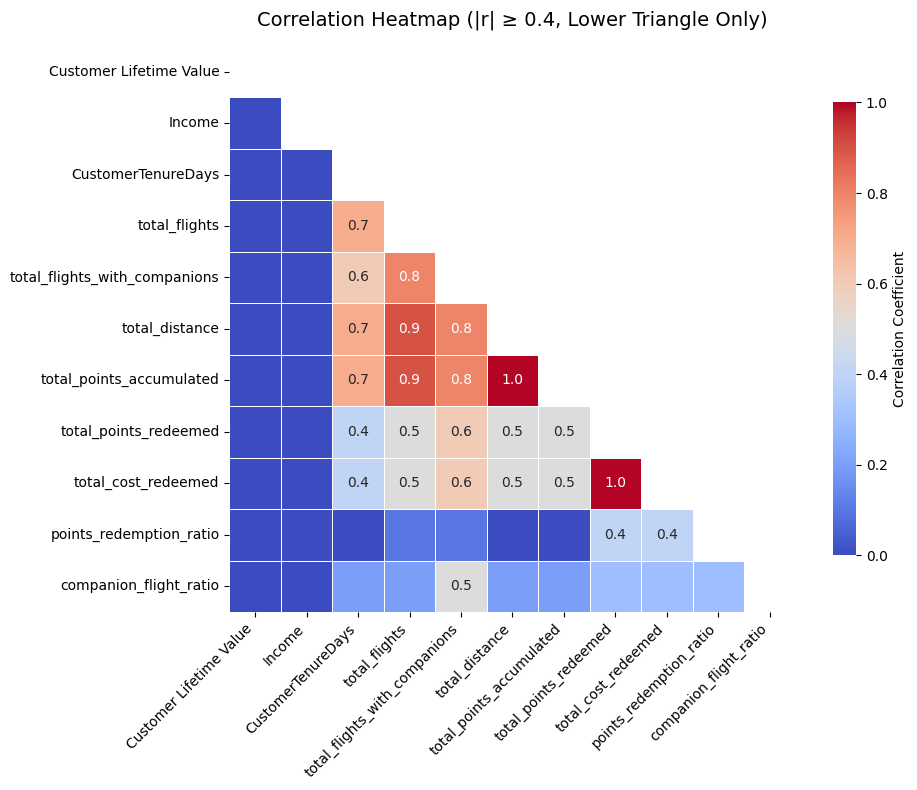

In [14]:
# ---- Compute correlation matrix ----
corr_matrix = df_val.corr(method='pearson').round(1)

# ---- Mask values below 0.4 ----
annot_matrix = corr_matrix.mask(corr_matrix.abs() < 0.4, "")

# ---- Create lower triangle mask ----
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# ---- Plot ----
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=annot_matrix,
    fmt='',
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Correlation Heatmap (|r| ≥ 0.4, Lower Triangle Only)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

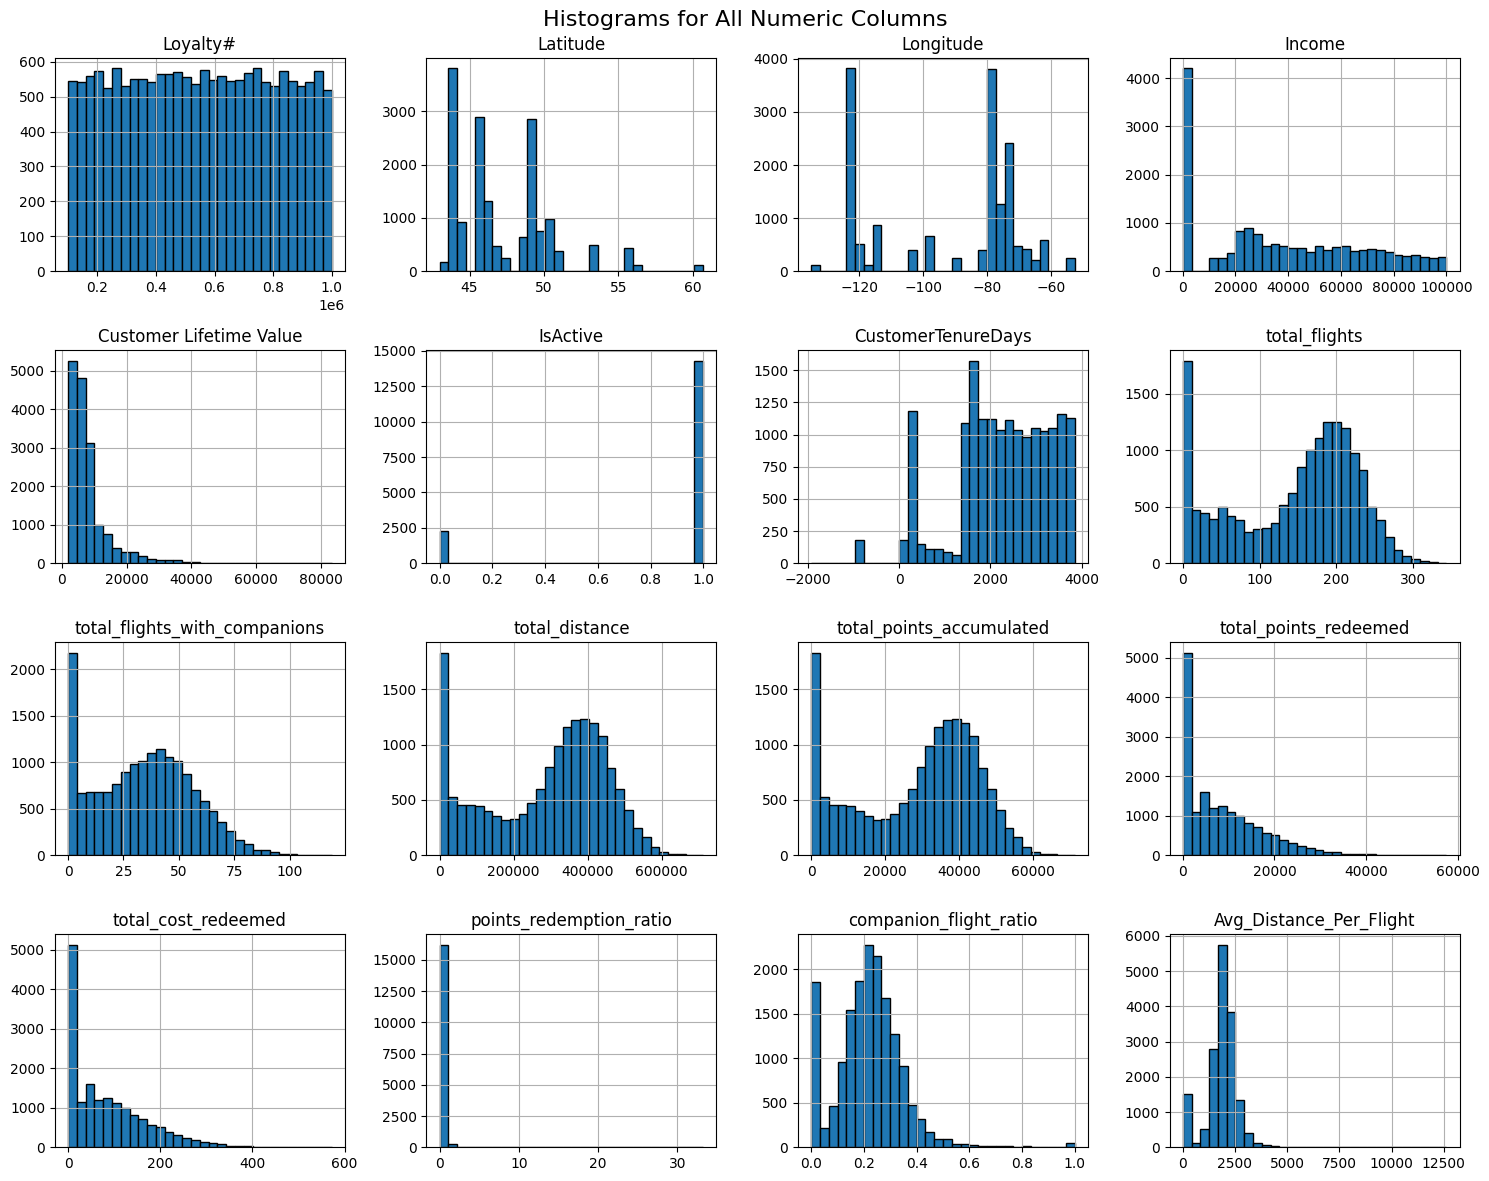

In [15]:
# Plot histograms for all numeric columns
customers.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Histograms for All Numeric Columns", fontsize=16)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frequency')

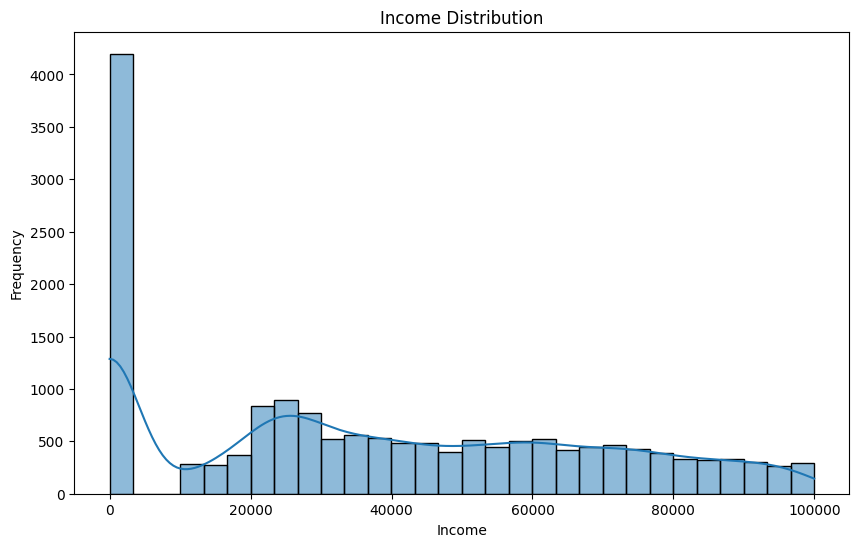

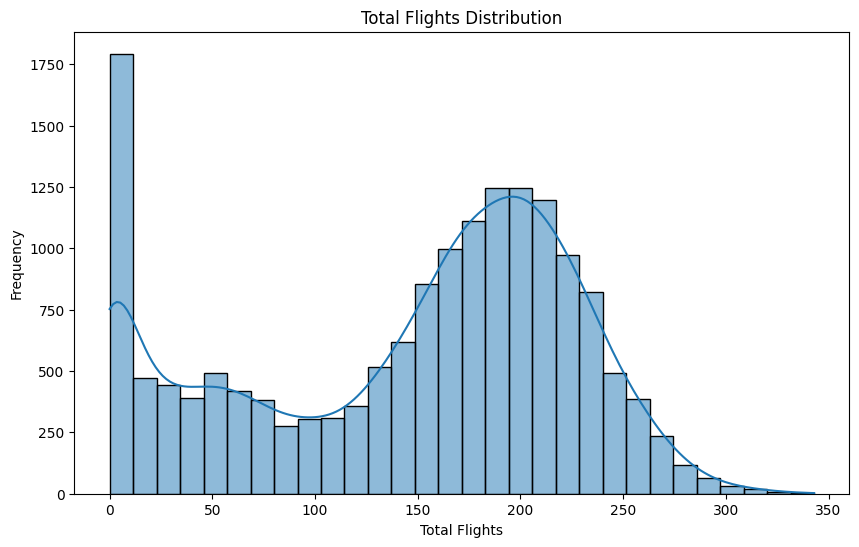

In [16]:
# Plot the income in a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=customers, x='Income', bins=30, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')

# Plot the total flights in a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=customers, x='total_flights', bins=30, kde=True)
plt.title('Total Flights Distribution')
plt.xlabel('Total Flights')
plt.ylabel('Frequency')


In [17]:
# Print the customers with 0 total flights
zero_flight_customers = customers[customers['total_flights'] == 0]
print(f"Number of customers with 0 total flights: {len(zero_flight_customers)}")

# Head of 3
zero_flight_customers.head(3)



Number of customers with 0 total flights: 1469


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio,Avg_Distance_Per_Flight
30,201574,Trudy,Roscoe,Trudy Roscoe,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,...,244,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,834891,Wendell,Besley,Wendell Besley,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,...,41,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,329382,Ngoc,Dubuisson,Ngoc Dubuisson,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 9K8,...,3700,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


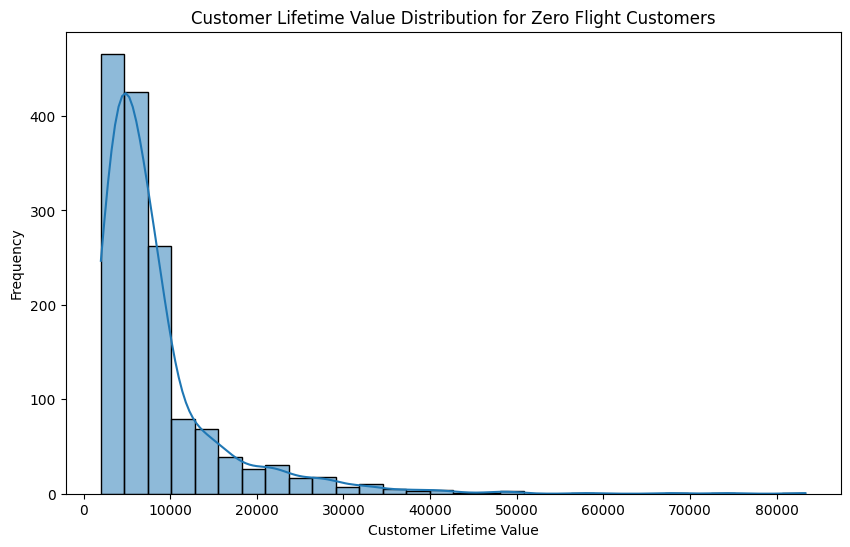

In [18]:
# Plot the Customer Lifetime Value of the zero flight customers
plt.figure(figsize=(10, 6))
sns.histplot(data=zero_flight_customers, x='Customer Lifetime Value', bins=30, kde=True)
plt.title('Customer Lifetime Value Distribution for Zero Flight Customers')
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Frequency')
plt.show()

In [19]:
# Show me the first 5 rows of zero_flight_customers dataframe with all columns
pd.set_option('display.max_columns', None)
zero_flight_customers.head(5)


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsActive,EndDate,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio,Avg_Distance_Per_Flight
30,201574,Trudy,Roscoe,Trudy Roscoe,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,Bachelor,Suburban,26605.0,Married,Star,2018-04-06,2018-12-06,3893.31,Standard,0,2018-12-06,244,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,834891,Wendell,Besley,Wendell Besley,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,female,Bachelor,Rural,30821.0,Married,Star,2020-03-08,2020-04-18,3911.12,Standard,0,2020-04-18,41,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,329382,Ngoc,Dubuisson,Ngoc Dubuisson,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 9K8,male,College,Suburban,0.0,Single,Star,2015-08-27,NaN,3961.59,2021 Promotion,1,2025-10-13,3700,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71,357549,Elisha,Furna,Elisha Furna,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Rural,60817.0,Single,Star,2021-09-21,2019-05-21,3964.73,Standard,0,2019-05-21,-854,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,283314,Vi,Scialdone,Vi Scialdone,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Suburban,54964.0,Married,Star,2016-04-17,2018-02-03,3991.73,Standard,0,2018-02-03,657,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


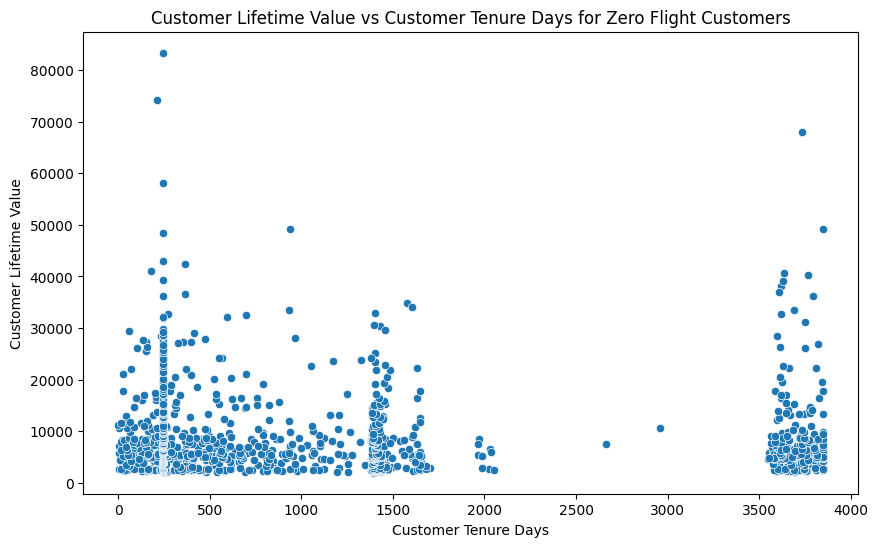

In [20]:
# Plot the Customer Lifetime Value and the CustomerTenureDays of the zero flight customers (exclude those with less than 1 day tenure)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=zero_flight_customers[zero_flight_customers['CustomerTenureDays'] > 0],
    x='CustomerTenureDays',
    y='Customer Lifetime Value'
)
plt.title('Customer Lifetime Value vs Customer Tenure Days for Zero Flight Customers')
plt.xlabel('Customer Tenure Days')
plt.ylabel('Customer Lifetime Value')
plt.show()

Income_Group
Very Low     6377
Low          2051
Medium       1577
High         2054
Very High    4515
Name: count, dtype: int64


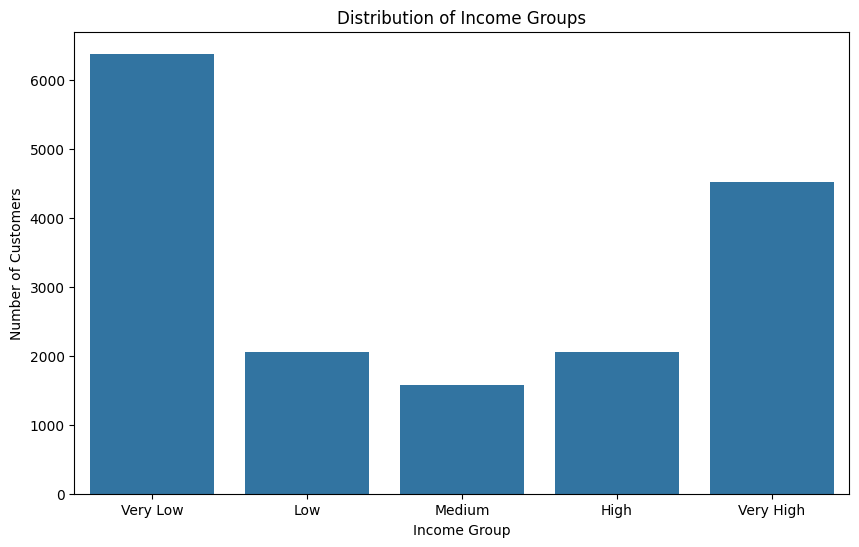

In [21]:
# Create a new column and groupBy Income ranges

ranked = customers['Income'].rank(method='first')  # bricht Ties deterministisch
customers['Income_Group'] = pd.qcut(
    ranked, q=5, labels=['Very Low','Low','Medium','High','Very High']
)

# Get the median Income from Statistca aroung 40k median income
# https://www.statista.com/statistics/464087/median-annual-earnings-in-canada/?srsltid=AfmBOorobKVMkA5XzryvSxoVhMDd2nOgjsvVJ3QwOdzoxHITF-YTxYi1
median_income = 40000

# Define custom bins around the median
bins = [0, 25000, 35000, 45000, 60000, customers['Income'].max()]

labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# Categorize based on custom bins
customers['Income_Group'] = pd.cut(customers['Income'], bins=bins, labels=labels, include_lowest=True)

# Check the distribution
print(customers['Income_Group'].value_counts().sort_index())

# Optional: check mean/median per group
#print(customers.groupby('Income_Group')['Income'].mean())
#print(customers.groupby('Income_Group')['Income'].median())

# Plot the distribution of Income_Group
plt.figure(figsize=(10, 6))
sns.countplot(data=customers, x='Income_Group', order=labels)
plt.title('Distribution of Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.show()


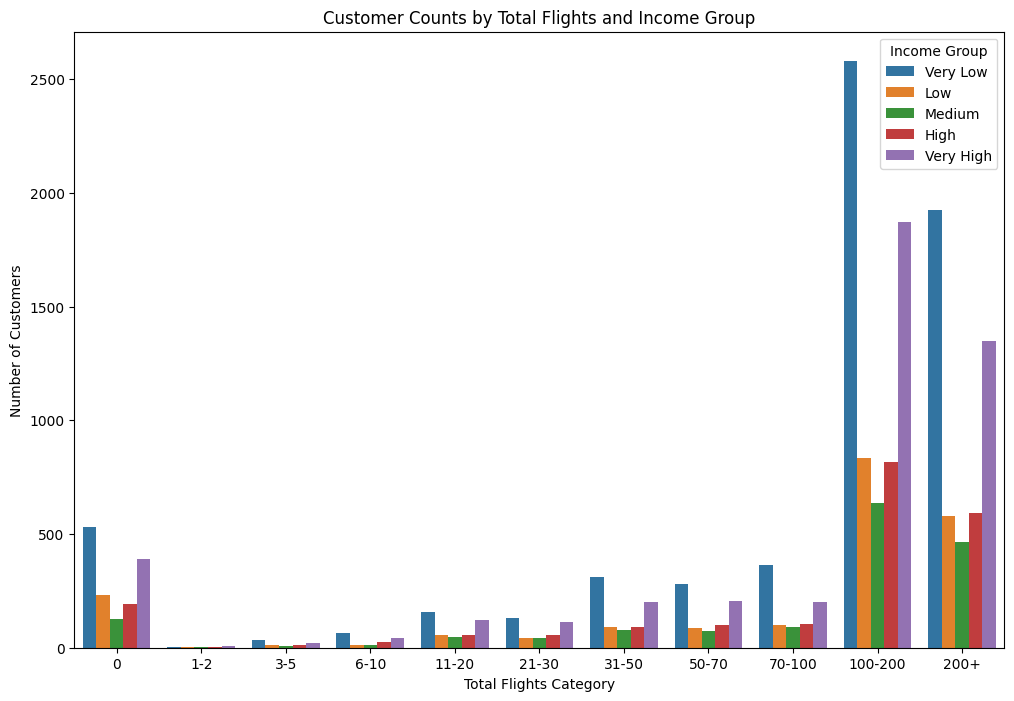

In [22]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of total_flights. 
# The total flights categories are 0, 1-2, 3-5, 5-10, 10-20, 20-30, 30-50, 50 - 70, 70-100, 100-200, 200+.
# For every income group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['total_flights'],
        bins=[0, 1, 3, 6, 11, 21, 31, 51 , 71, 101, 201, np.inf],
        labels=['0', '1-2', '3-5', '6-10', '11-20', '21-30', '31-50', '50-70', '70-100', '100-200','200+'],
                        right=False
    ),
    hue='Income_Group',
    order=['0', '1-2', '3-5', '6-10', '11-20', '21-30', '31-50', '50-70', '70-100', '100-200','200+']
)
plt.title('Customer Counts by Total Flights and Income Group')
plt.xlabel('Total Flights Category')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.show()


In [23]:
# Calculate mean total_flights per Income_Group
means = customers.groupby('Income_Group')['total_flights'].mean().sort_index()

# Print the mean values
print("Mean total flights per Income Group:")
for group, mean in means.items():
    print(f"{group}: {mean:.1f}")


Mean total flights per Income Group:
Very Low: 146.4
Low: 141.5
Medium: 144.5
High: 141.6
Very High: 145.6


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_80764/1262035807.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = customers.groupby('Income_Group')['total_flights'].mean().sort_index()


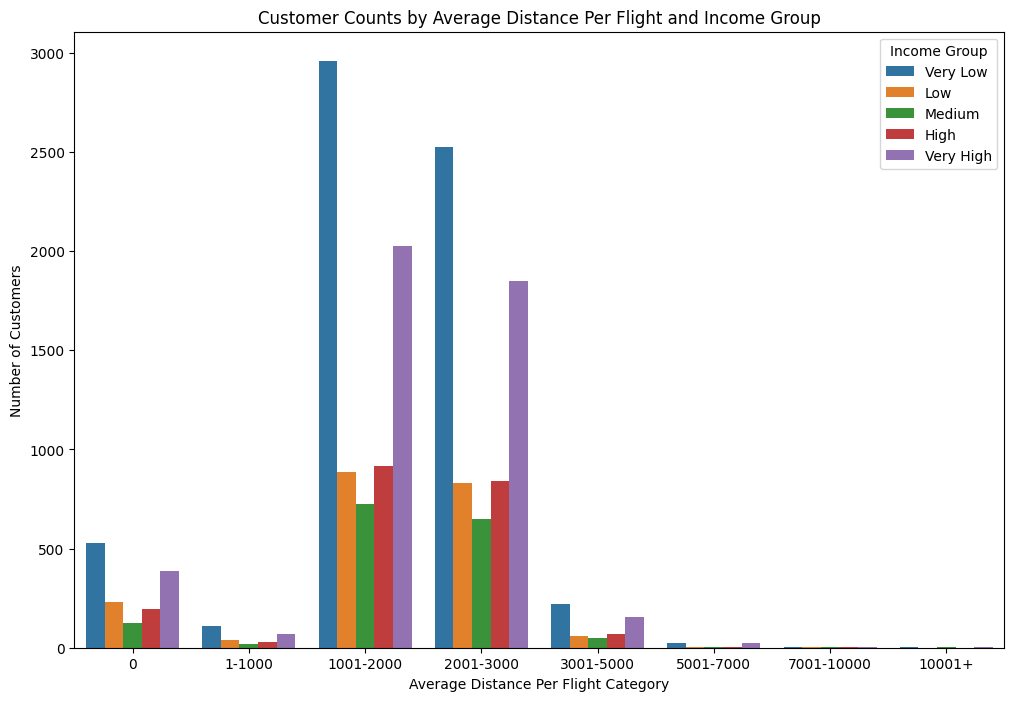

In [24]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of average_distance.
# The average distance categories are 0, 1 - 1000, 1001 - 2000, 2001- 3000, 3001 - 5000, 5001 - 7000, 7001 - 10000, 10001+.
# For every income group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['Avg_Distance_Per_Flight'],
        bins=[-1, 0, 1000, 2000, 3000, 5000, 7000, 10000, np.inf],
        labels=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+'],
                        right=True
    ),
    hue='Income_Group',
    order=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+']
)
plt.title('Customer Counts by Average Distance Per Flight and Income Group')
plt.xlabel('Average Distance Per Flight Category')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.show()



In [25]:
# Create a new column and groupBy CLV ranges
ranked_clv = customers['Customer Lifetime Value'].rank(method='first')  # bricht Ties deterministisch
customers['CLV_Group'] = pd.qcut(
    ranked_clv, q=5, labels=['Very Low','Low','Medium','High','Very High']
)

clv_distribution = customers['CLV_Group'].value_counts().sort_index()

# Print the quantile value of CLV_Group
clv_quantiles = customers['Customer Lifetime Value'].quantile([0.2, 0.4, 0.6, 0.8])
print("Customer Lifetime Value Quantiles:")
print(clv_quantiles)

Customer Lifetime Value Quantiles:
0.2     3434.678
0.4     5119.900
0.6     7254.378
0.8    10179.720
Name: Customer Lifetime Value, dtype: float64


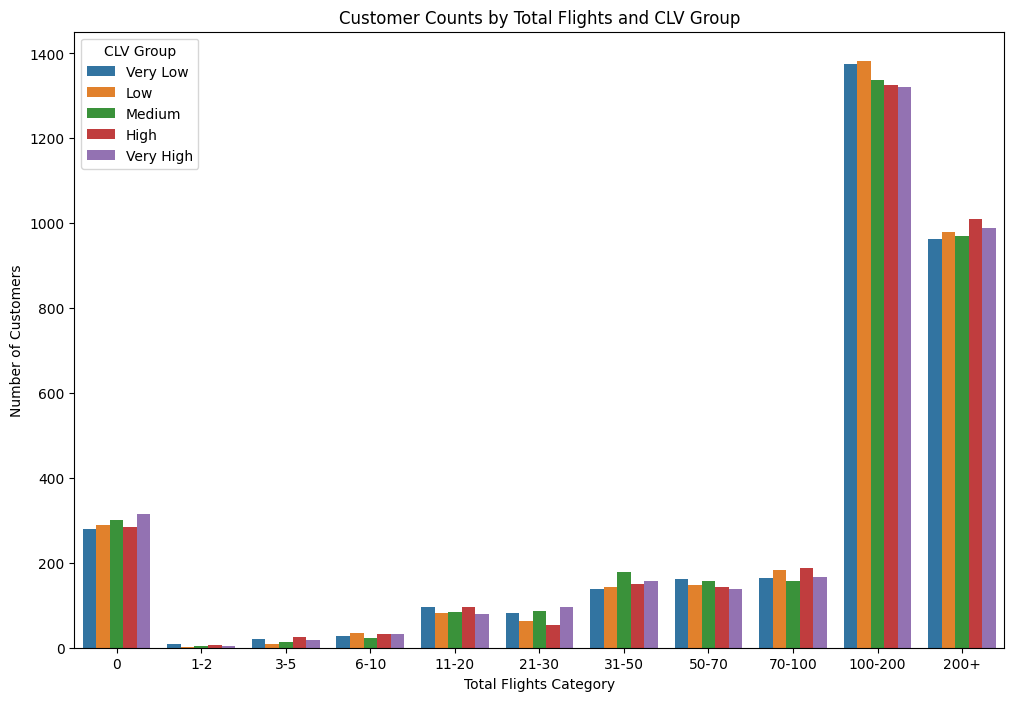

In [26]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of total_flights. 
# The total flights categories are 0, 1-2, 3-5, 5-10, 10-20, 20-30, 30-50, 50 - 70, 70-100, 100-200, 200+.
# For every CLV_Group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['total_flights'],
        bins=[0, 1, 3, 6, 11, 21, 31, 51 , 71, 101, 201, np.inf],
        labels=['0', '1-2', '3-5', '6-10', '11-20', '21-30', '31-50', '50-70', '70-100', '100-200','200+'],
                        right=False
    ),
    hue='CLV_Group',
    order=['0', '1-2', '3-5', '6-10', '11-20', '21-30', '31-50', '50-70', '70-100', '100-200','200+']
)
plt.title('Customer Counts by Total Flights and CLV Group')
plt.xlabel('Total Flights Category')
plt.ylabel('Number of Customers')
plt.legend(title='CLV Group')
plt.show()

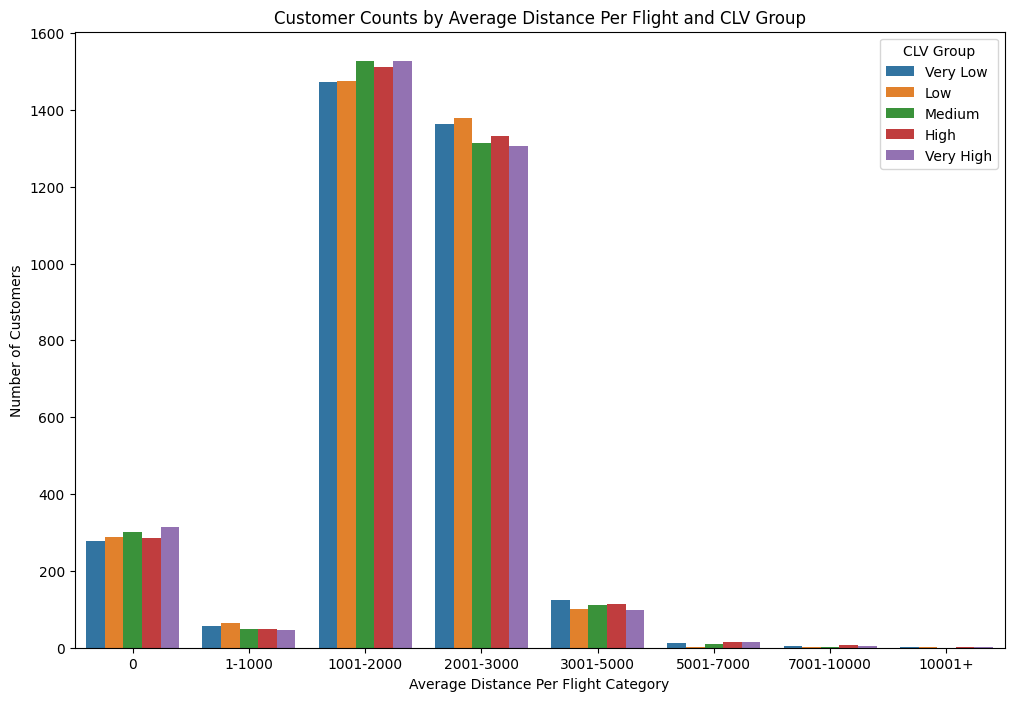

In [27]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of average_distance.
# The average distance categories are 0, 1 - 1000, 1001 - 2000, 2001- 3000, 3001 - 5000, 5001 - 7000, 7001 - 10000, 10001+.
# For every CLV_Group, plot a separate bar chart with different colors.

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['Avg_Distance_Per_Flight'],
        bins=[-1, 0, 1000, 2000, 3000, 5000, 7000, 10000, np.inf],
        labels=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+'],
                        right=True
    ),
    hue='CLV_Group',
    order=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+']
)
plt.title('Customer Counts by Average Distance Per Flight and CLV Group')
plt.xlabel('Average Distance Per Flight Category')
plt.ylabel('Number of Customers')
plt.legend(title='CLV Group')
plt.show()


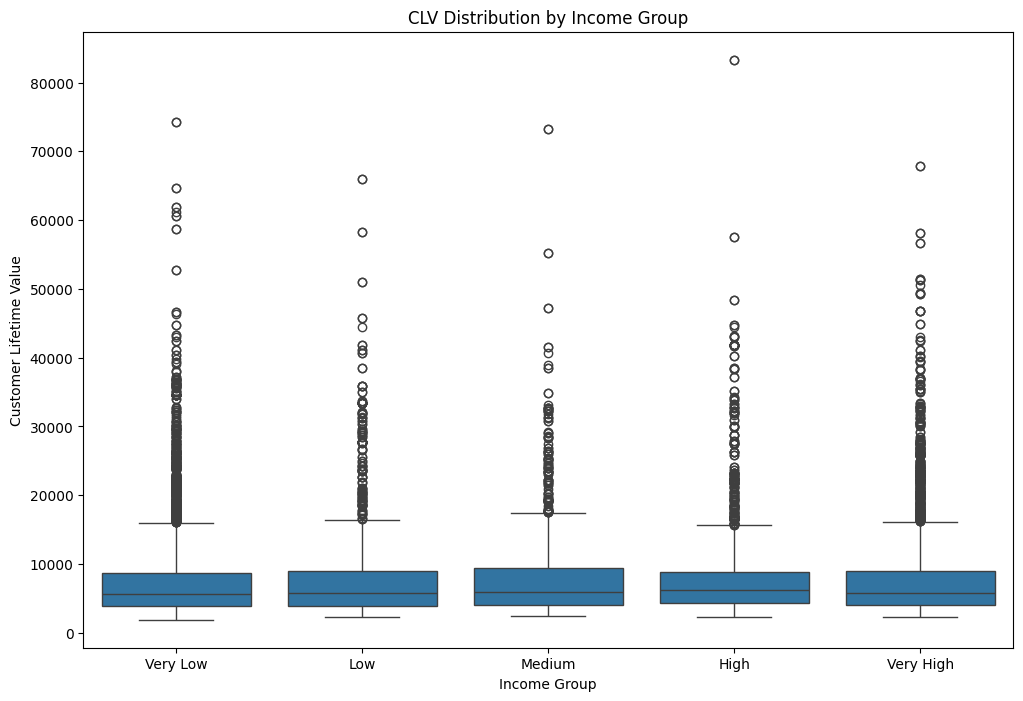

In [28]:
# 4️⃣ Analyse der CLV-Verteilung pro Einkommensgruppe

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=customers,
    x='Income_Group',
    y='Customer Lifetime Value',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
plt.title('CLV Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Customer Lifetime Value')
plt.show()

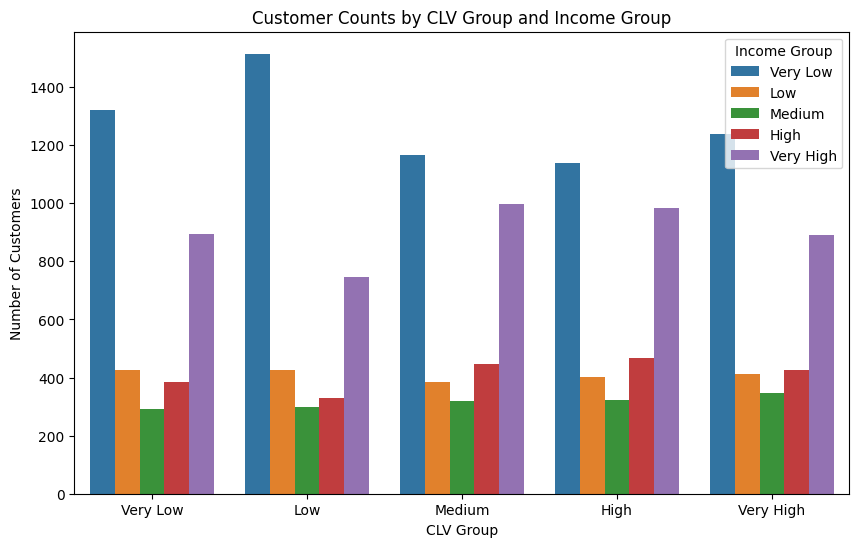

In [29]:
# CLV_Group und Income Group Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Income_Group',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
plt.title('Customer Counts by CLV Group and Income Group')
plt.xlabel('CLV Group')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.show()

In [30]:
# Kreuztabelle von CLV_Group und Income_Group
clv_income_crosstab = pd.crosstab(customers['CLV_Group'], customers['Income_Group'], normalize='index') * 100
print(clv_income_crosstab)

Income_Group   Very Low        Low     Medium       High  Very High
CLV_Group                                                          
Very Low      39.819005  12.880845   8.808446  11.553544  26.938160
Low           45.701357  12.850679   8.959276   9.954751  22.533937
Medium        35.214243  11.557031   9.656005  13.427882  30.144840
High          34.328808  12.126697   9.713424  14.147813  29.683258
Very High     37.315234  12.458522  10.437406  12.880845  26.907994


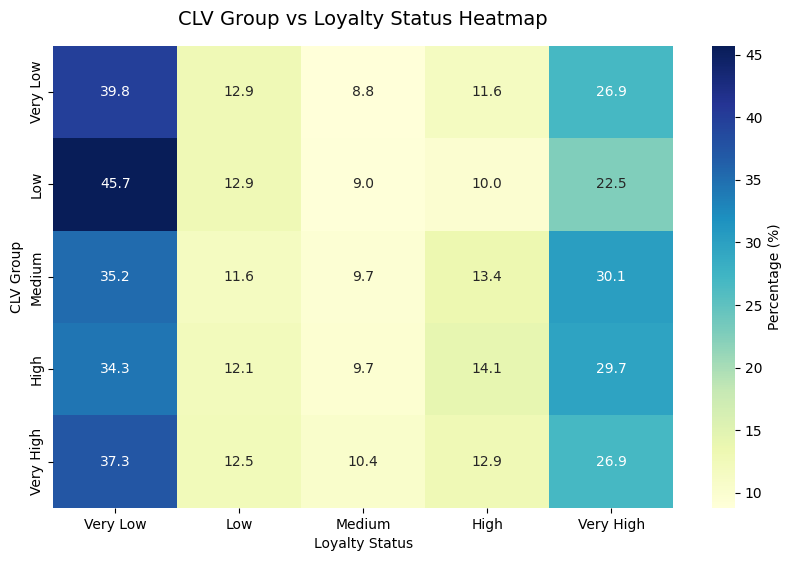

In [31]:
# Visualisierung der Kreuztabelle als Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    clv_income_crosstab,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"}
)
plt.title("CLV Group vs Loyalty Status Heatmap", fontsize=14, pad=15)
plt.xlabel("Loyalty Status")
plt.ylabel("CLV Group")
plt.show()

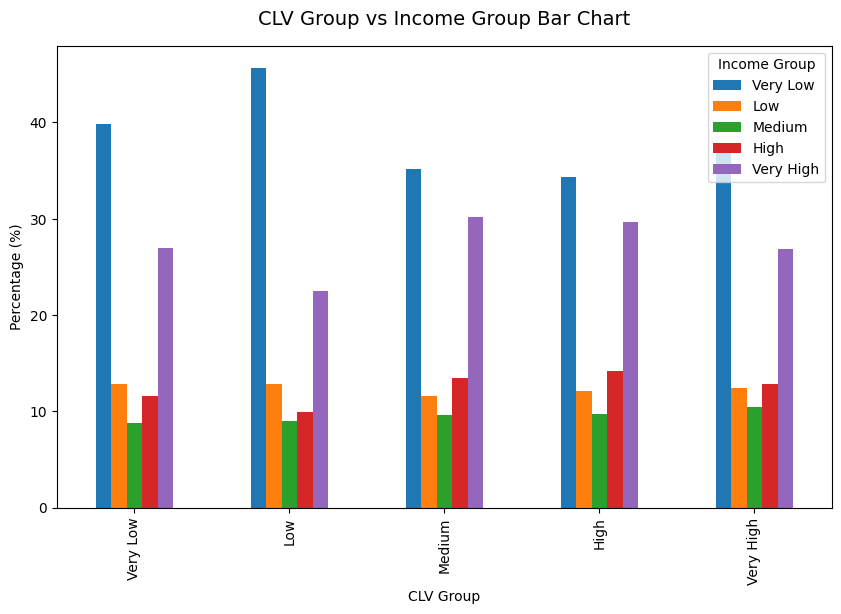

In [32]:
# Visualisierung der Kreuztabelle als Bar Chart
clv_income_crosstab.plot(kind='bar', figsize=(10, 6))
plt.title("CLV Group vs Income Group Bar Chart", fontsize=14, pad=15)
plt.xlabel("CLV Group")
plt.ylabel("Percentage (%)")
plt.legend(title='Income Group')
plt.show()

# Loyalty Status Distribution across CLV Groups and Income Groups

In [33]:
# Kombinieren mit LoyaltyStatus in einer Kreuztabelle


clv_loyalty_crosstab = pd.crosstab(customers['CLV_Group'], customers['LoyaltyStatus'], normalize='index') * 100
print(clv_loyalty_crosstab)

LoyaltyStatus     Aurora       Nova       Star
CLV_Group                                     
Very Low        0.000000  27.330317  72.669683
Low             4.705882  39.668175  55.625943
Medium         32.468316  34.127942  33.403742
High           31.975867  34.630468  33.393665
Very High      32.368024  33.514329  34.117647


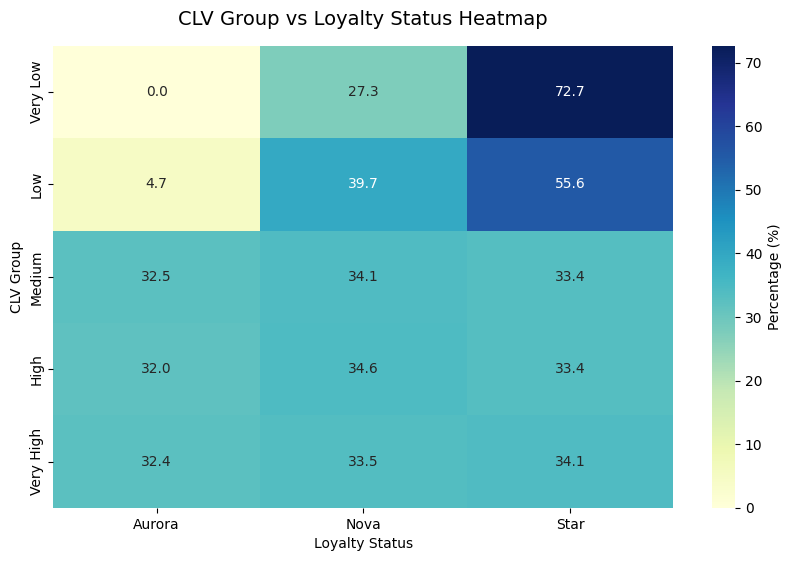

In [34]:
# Visualisierung der Kreuztabelle als Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    clv_loyalty_crosstab,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"}
)
plt.title("CLV Group vs Loyalty Status Heatmap", fontsize=14, pad=15)
plt.xlabel("Loyalty Status")
plt.ylabel("CLV Group")
plt.show()

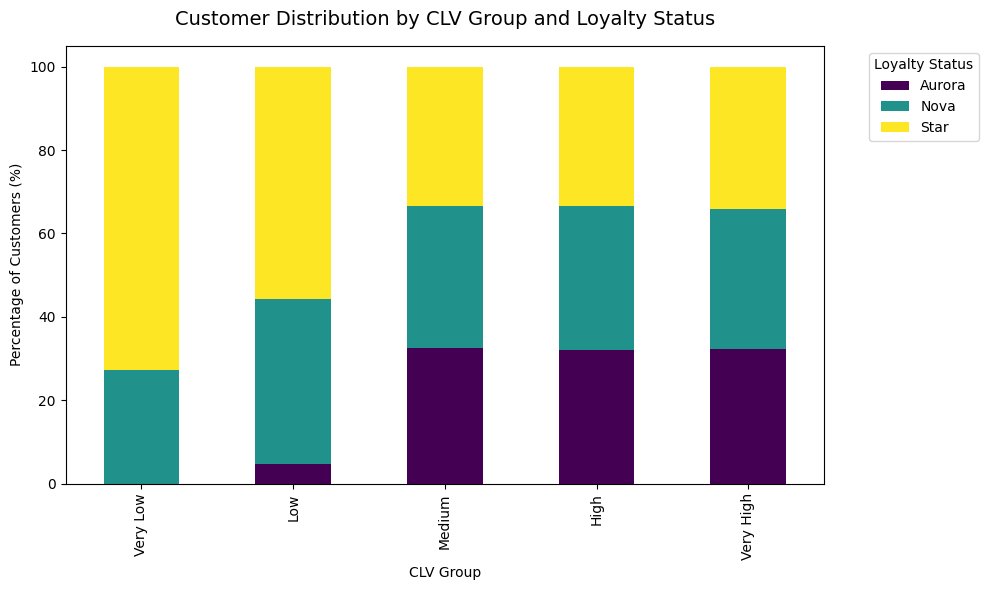

In [35]:
# Visualisierung der Kreuztabelle als Stack Chart

clv_loyalty_crosstab.plot(
    kind='bar',
    figsize=(10, 6),
    stacked=True,
    colormap='viridis'
)
plt.title("Customer Distribution by CLV Group and Loyalty Status", fontsize=14, pad=15)
plt.xlabel("CLV Group")
plt.ylabel("Percentage of Customers (%)")
plt.legend(title='Loyalty Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

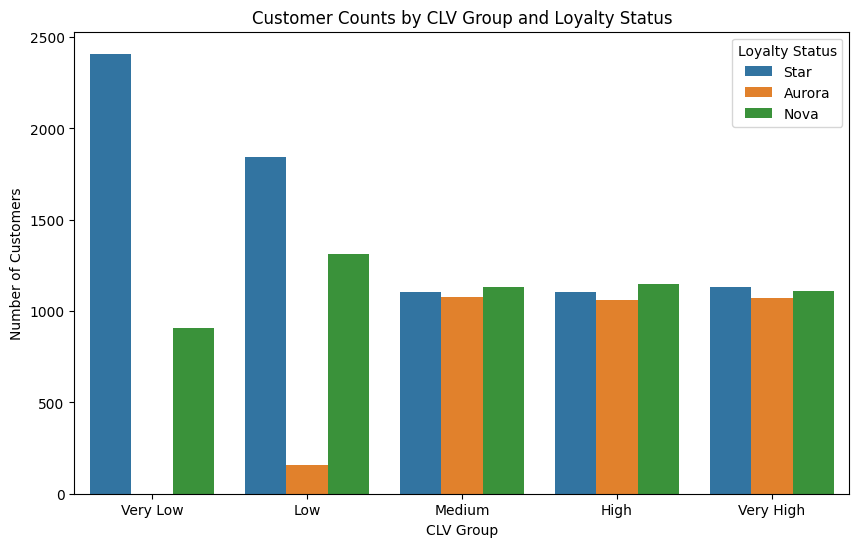

In [36]:
# Plot LoyaltyStatus with CLV_Group in a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='LoyaltyStatus',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
plt.title('Customer Counts by CLV Group and Loyalty Status')
plt.xlabel('CLV Group')
plt.ylabel('Number of Customers')
plt.legend(title='Loyalty Status')
plt.show()

In [37]:
# Kombinieren von Income mit LoyaltyStatus in einer Kreuztabelle

clv_loyalty_crosstab = pd.crosstab(customers['Income_Group'], customers['LoyaltyStatus'], normalize='index') * 100
print(clv_loyalty_crosstab)

LoyaltyStatus     Aurora       Nova       Star
Income_Group                                  
Very Low       18.378548  32.209503  49.411949
Low            19.795222  33.398342  46.806436
Medium         21.369689  36.651871  41.978440
High           20.837390  34.615385  44.547225
Very High      22.635659  35.060908  42.303433


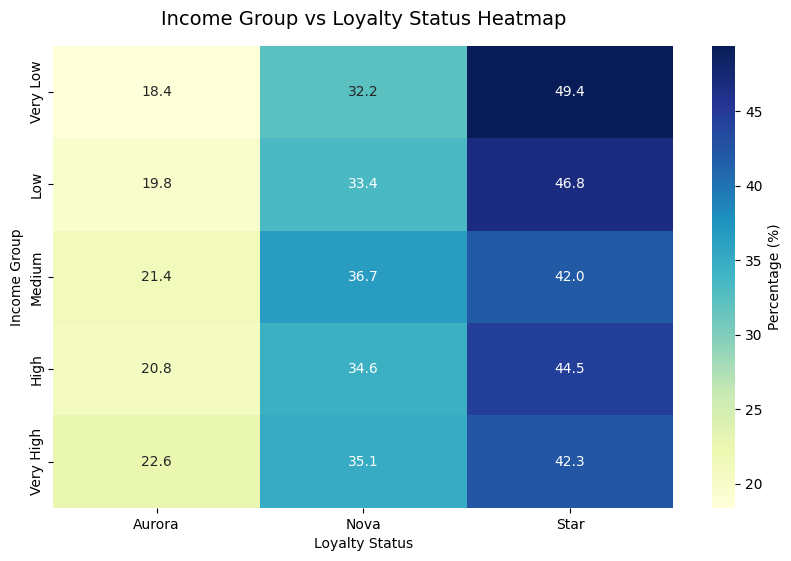

In [38]:
# Visualisierung der Kreuztabelle als Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    clv_loyalty_crosstab,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"}
)
plt.title("Income Group vs Loyalty Status Heatmap", fontsize=14, pad=15)
plt.xlabel("Loyalty Status")
plt.ylabel("Income Group")
plt.show()